In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score


import pickle

In [2]:
df = pd.read_csv("/kaggle/input/college-admission-dataset-india/College_Admission.csv")

In [3]:
df.head()

,student_id,age,gender,category,state,preferred_stream,entrance_exam,entrance_score,board_percentage,extracurricular_score,admission_probability,admission_status,scholarship_eligibility
0,250.99,17,other,general,odisha,management,cet,30,95.58,2,0.387,admitted,yes
1,250.99,20,other,ews,gujarat,agriculture,none,0,75.45,2,0.221,rejected,no
2,250.99,19,female,sc,uttar pradesh,pharmacy,cet,120,75.36,10,0.446,rejected,no
3,250.99,18,male,ews,meghalaya,arts,cet,179,52.49,2,0.174,admitted,no
4,250.99,18,male,sc,rajasthan,engineering,jee,295,92.48,7,0.634,admitted,yes


### Droping "student_id" Column :

In [4]:
df.drop(columns = "student_id", inplace = True)

### Checking NULL values :

In [5]:
df.isnull().sum()

age                        0
gender                     0
category                   0
state                      0
preferred_stream           0
entrance_exam              0
entrance_score             0
board_percentage           0
extracurricular_score      0
admission_probability      0
admission_status           0
scholarship_eligibility    0
dtype: int64

### Checking Duplicates :

In [6]:
df.duplicated().sum()

0

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      25000 non-null  int64  
 1   gender                   25000 non-null  object 
 2   category                 25000 non-null  object 
 3   state                    25000 non-null  object 
 4   preferred_stream         25000 non-null  object 
 5   entrance_exam            25000 non-null  object 
 6   entrance_score           25000 non-null  int64  
 7   board_percentage         25000 non-null  float64
 8   extracurricular_score    25000 non-null  int64  
 9   admission_probability    25000 non-null  float64
 10  admission_status         25000 non-null  object 
 11  scholarship_eligibility  25000 non-null  object 
dtypes: float64(2), int64(3), object(7)
memory usage: 2.3+ MB


In [8]:
obj_cols_list = df.select_dtypes("object").columns.tolist()

In [9]:
obj_cols_list

['gender',
 'category',
 'state',
 'preferred_stream',
 'entrance_exam',
 'admission_status',
 'scholarship_eligibility']

In [10]:
for col in obj_cols_list:
    print(df[col].value_counts())

gender
other     8387
male      8364
female    8249
Name: count, dtype: int64
category
st         5081
obc        5022
sc         5001
general    4963
ews        4933
Name: count, dtype: int64
state
rajasthan            1031
karnataka            1014
gujarat              1008
himachal pradesh      991
assam                 990
punjab                985
chhattisgarh          981
uttar pradesh         978
meghalaya             978
tamil nadu            976
maharashtra           973
nagaland              965
arunachal pradesh     960
telangana             958
jharkhand             955
mizoram               955
odisha                953
bihar                 949
sikkim                948
andhra pradesh        947
tripura               942
manipur               939
madhya pradesh        925
haryana               921
goa                   890
kerala                888
Name: count, dtype: int64
preferred_stream
management               2163
arts                     2135
nursing               

### Encoding :

In [11]:
obj_cols_list

encoder = LabelEncoder()

for col in obj_cols_list:
    df[col]= encoder.fit_transform(df[col])

In [12]:
df

,age,gender,category,state,preferred_stream,entrance_exam,entrance_score,board_percentage,extracurricular_score,admission_probability,admission_status,scholarship_eligibility
0,17,2,1,18,7,0,30,95.58,2,0.387,0,1
1,20,2,0,6,0,3,0,75.45,2,0.221,1,0
2,19,0,3,25,10,0,120,75.36,10,0.446,1,0
3,18,1,0,15,2,0,179,52.49,2,0.174,0,0
4,18,1,3,20,5,1,295,92.48,7,0.634,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...
24995,18,0,2,25,6,3,0,82.67,2,0.273,1,0
24996,20,2,0,0,7,3,0,60.66,10,0.258,1,0
24997,17,1,2,14,10,0,195,91.87,6,0.544,1,0
24998,19,1,0,0,7,0,66,50.44,9,0.209,1,0


In [13]:
df.describe()

,age,gender,category,state,preferred_stream,entrance_exam,entrance_score,board_percentage,extracurricular_score,admission_probability,admission_status,scholarship_eligibility
count,25000.000000,25000.000000,25000.000000,25000.000000,25000.00000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000
mean,18.492440,1.005520,2.013360,12.531920,5.47528,1.567080,77.879760,75.028014,4.990920,0.323997,0.673920,0.202160
std,1.116205,0.815743,1.414462,7.507892,3.45014,1.408283,120.356125,14.438767,3.158942,0.142427,0.468786,0.401619
min,17.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,50.440000,0.000000,0.041990,0.000000,0.000000
25%,17.000000,0.000000,1.000000,6.000000,2.00000,0.000000,0.000000,62.550000,2.000000,0.219000,0.000000,0.000000
50%,18.000000,1.000000,2.000000,13.000000,5.00000,2.000000,20.000000,75.070000,5.000000,0.319000,1.000000,0.000000
75%,19.000000,2.000000,3.000000,19.000000,8.00000,3.000000,126.000000,87.640000,8.000000,0.419000,1.000000,0.000000
max,20.000000,2.000000,4.000000,25.000000,11.00000,3.000000,634.000000,99.530000,10.000000,0.731010,1.000000,1.000000


In [14]:
int_cols_list = df.select_dtypes("int64").columns.tolist()

In [15]:
int_cols_list

['age',
 'gender',
 'category',
 'state',
 'preferred_stream',
 'entrance_exam',
 'entrance_score',
 'extracurricular_score',
 'admission_status',
 'scholarship_eligibility']

In [16]:
print(pd.DataFrame({"min": df.select_dtypes("int64").min(), "max": df.select_dtypes("int64").max(), "avg": df.select_dtypes("int64").mean()}))

                         min  max       avg
age                       17   20  18.49244
gender                     0    2   1.00552
category                   0    4   2.01336
state                      0   25  12.53192
preferred_stream           0   11   5.47528
entrance_exam              0    3   1.56708
entrance_score             0  634  77.87976
extracurricular_score      0   10   4.99092
admission_status           0    1   0.67392
scholarship_eligibility    0    1   0.20216


In [17]:
float_cols_list = df.select_dtypes("float64").columns.tolist()

In [18]:
float_cols_list

['board_percentage', 'admission_probability']

In [19]:
print(pd.DataFrame({"min": df.select_dtypes("float64").min(), "max": df.select_dtypes("float64").max(), "avg" : df.select_dtypes("float64").mean()}))

                            min       max        avg
board_percentage       50.44000  99.53000  75.028014
admission_probability   0.04199   0.73101   0.323997


### Outlier Detection: 

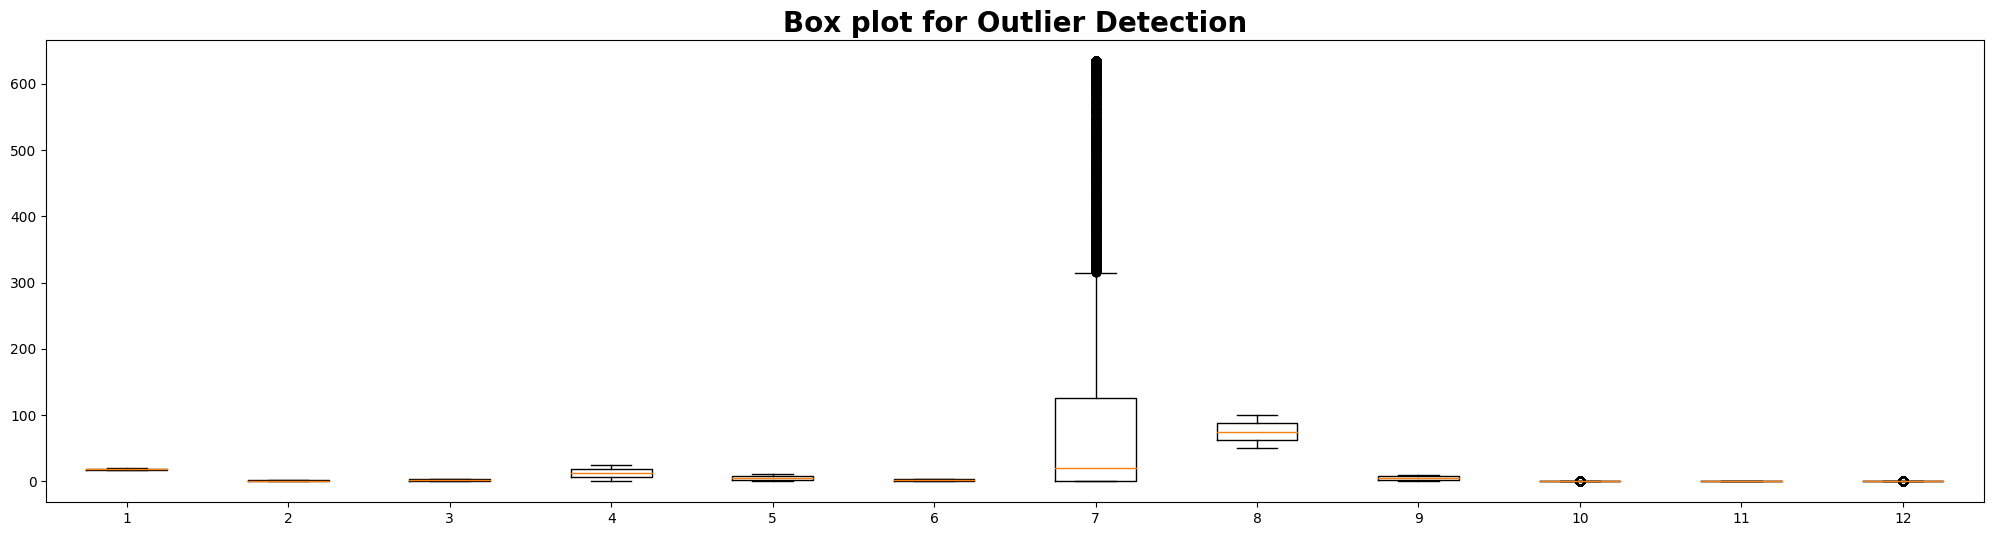

In [20]:
plt.figure(figsize = (25, 6), dpi = 100, facecolor = "white", edgecolor = "black")
plt.boxplot(
    df
)
plt.title("Box plot for Outlier Detection", fontsize = 20, color = "black", fontweight = "bold", loc = "center")
plt.show()

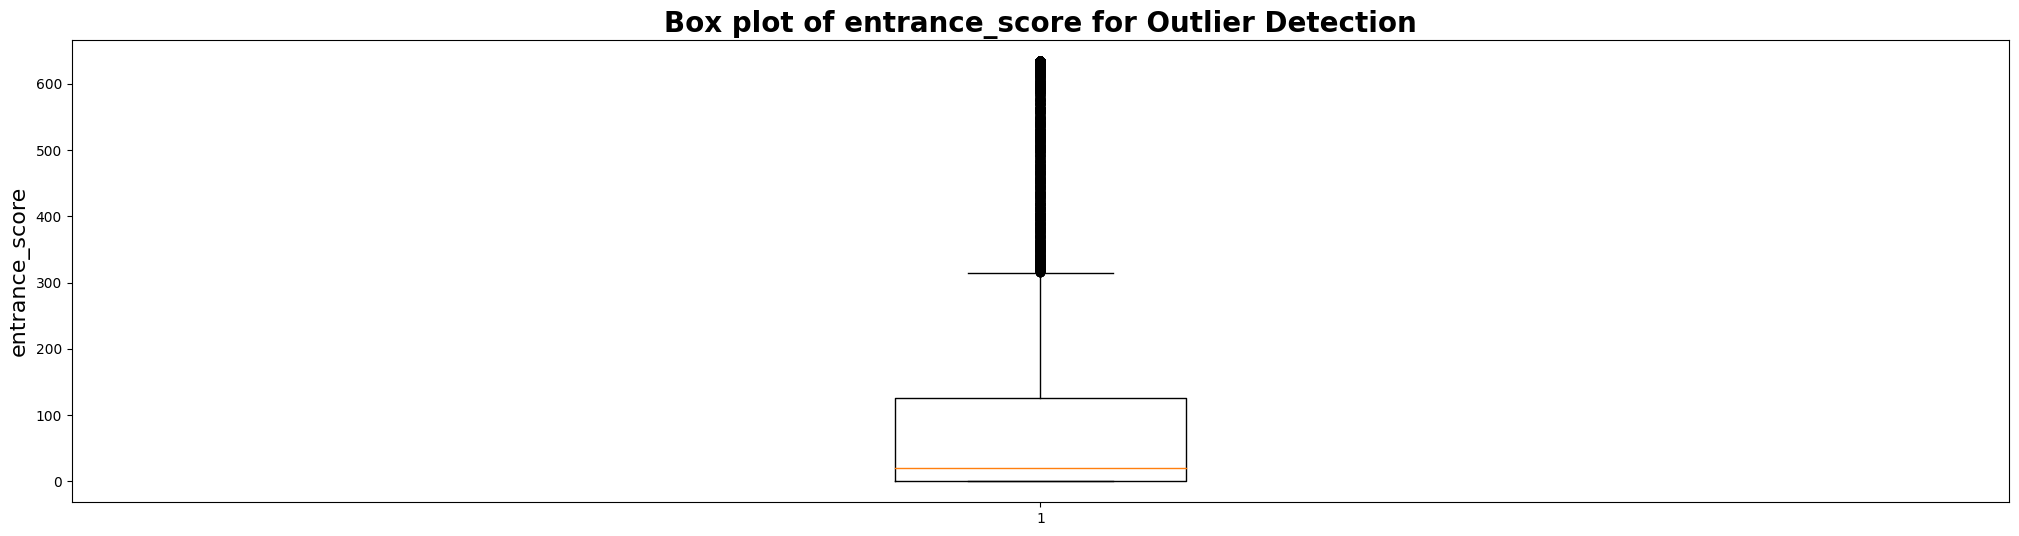

In [21]:
plt.figure(figsize = (25, 6), dpi = 100, facecolor = "white", edgecolor = "black")
plt.boxplot(
    df["entrance_score"]
)
plt.title("Box plot of entrance_score for Outlier Detection", fontsize = 20, color = "black", fontweight = "bold", loc = "center")
plt.ylabel("entrance_score", fontsize = 16)
plt.show()

### Outlier Handling :

In [22]:
Q1 = np.percentile(df["entrance_score"], 25)
Q3 = np.percentile(df["entrance_score"], 75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df.loc[(df["entrance_score"] < lower_bound) | (df['entrance_score'] > upper_bound), "entrance_score"] = df["entrance_score"].median()

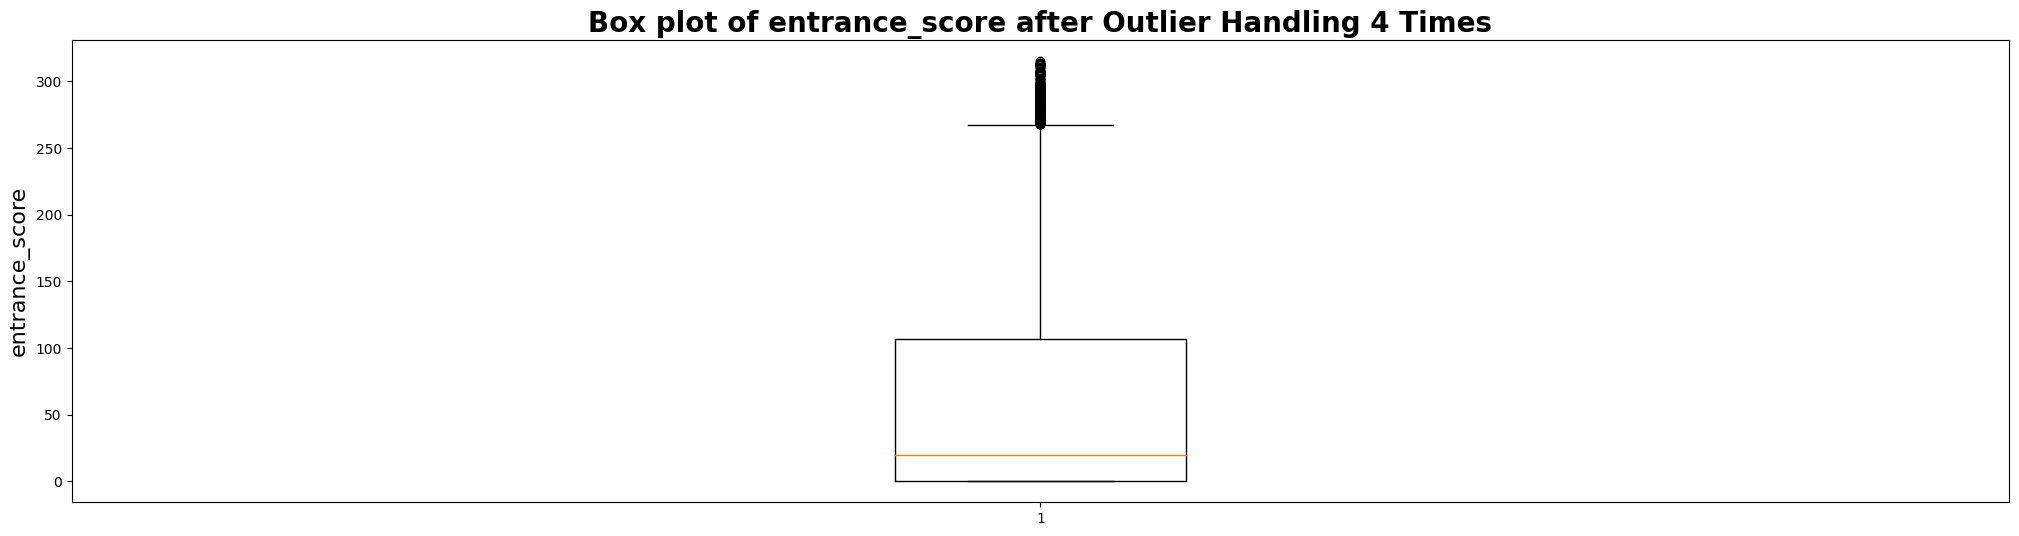

In [23]:
plt.figure(figsize = (25, 6), dpi = 100, facecolor = "white", edgecolor = "black")
plt.boxplot(
    df["entrance_score"]
)
plt.title("Box plot of entrance_score after Outlier Handling 4 Times", fontsize = 20, color = "black", fontweight = "bold", loc = "center")
plt.ylabel("entrance_score", fontsize = 16)
plt.show()

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      25000 non-null  int64  
 1   gender                   25000 non-null  int64  
 2   category                 25000 non-null  int64  
 3   state                    25000 non-null  int64  
 4   preferred_stream         25000 non-null  int64  
 5   entrance_exam            25000 non-null  int64  
 6   entrance_score           25000 non-null  int64  
 7   board_percentage         25000 non-null  float64
 8   extracurricular_score    25000 non-null  int64  
 9   admission_probability    25000 non-null  float64
 10  admission_status         25000 non-null  int64  
 11  scholarship_eligibility  25000 non-null  int64  
dtypes: float64(2), int64(10)
memory usage: 2.3 MB


### Plots :

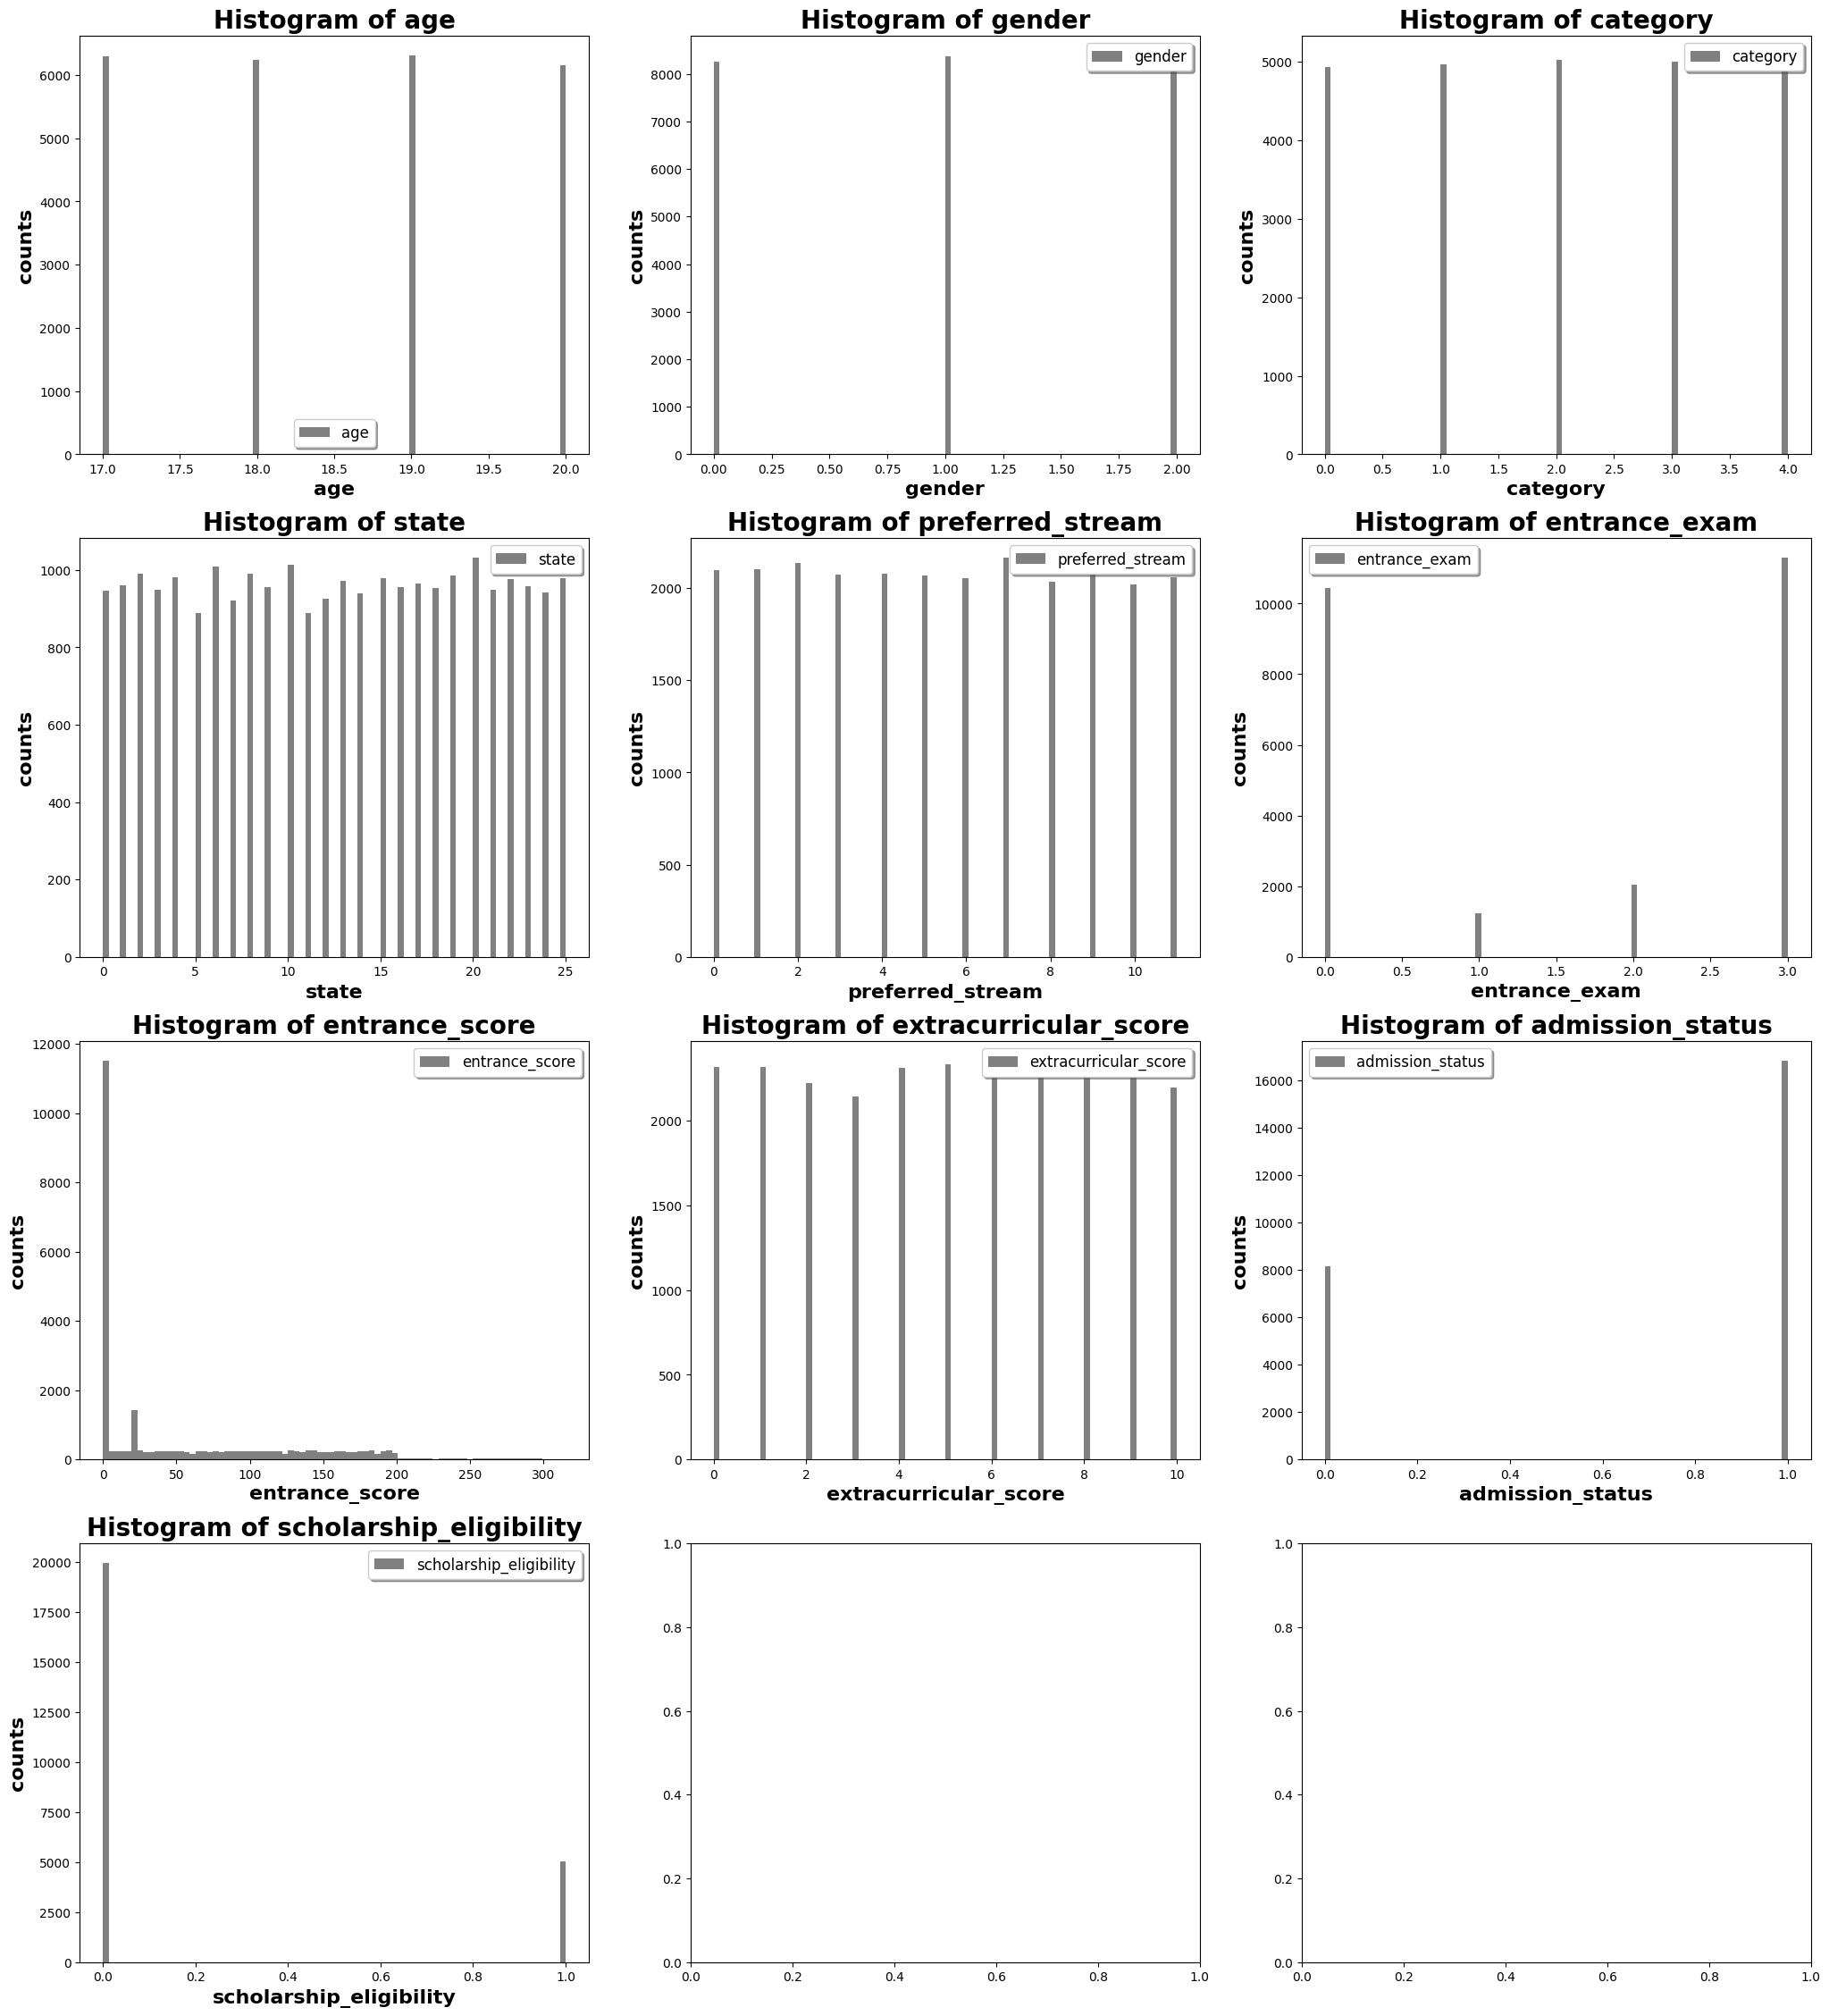

In [25]:
int_cols_list = df.select_dtypes("int64").columns.tolist()

rows = 4
fig, axes = plt.subplots(rows, 3 , figsize = (25, 7 * rows))
axes = axes.flatten()

for ax, col in zip(axes, int_cols_list):
    ax.hist(
        df[col],
        color = "grey",
        label = f"{col}",
        bins = 80,
    )
    ax.set_title(f"Histogram of {col}", fontsize = 20, color = "black", loc = "center" , fontweight = "bold")
    ax.set_xlabel(f"{col}", fontsize = 16, fontweight = "bold", color = "black")
    ax.set_ylabel("counts", fontsize = 16, fontweight = "bold", color = "black")
    ax.legend(shadow = True, fontsize = 12)
plt.show()

In [26]:
df

,age,gender,category,state,preferred_stream,entrance_exam,entrance_score,board_percentage,extracurricular_score,admission_probability,admission_status,scholarship_eligibility
0,17,2,1,18,7,0,30,95.58,2,0.387,0,1
1,20,2,0,6,0,3,0,75.45,2,0.221,1,0
2,19,0,3,25,10,0,120,75.36,10,0.446,1,0
3,18,1,0,15,2,0,179,52.49,2,0.174,0,0
4,18,1,3,20,5,1,295,92.48,7,0.634,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...
24995,18,0,2,25,6,3,0,82.67,2,0.273,1,0
24996,20,2,0,0,7,3,0,60.66,10,0.258,1,0
24997,17,1,2,14,10,0,195,91.87,6,0.544,1,0
24998,19,1,0,0,7,0,66,50.44,9,0.209,1,0


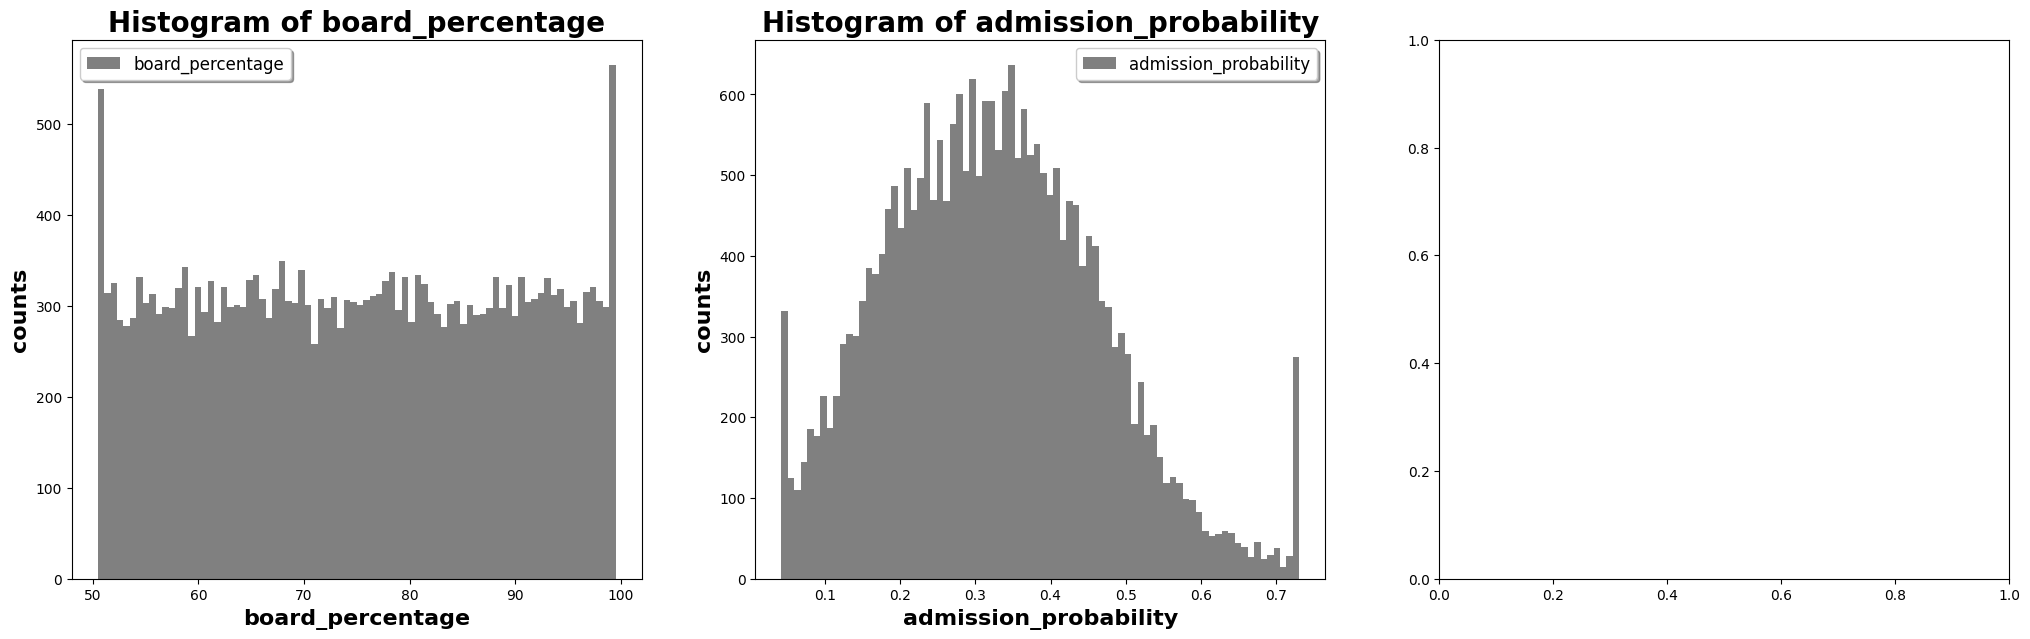

In [27]:
float_cols_list = df.select_dtypes("float64").columns.tolist()

rows = 1
fig, axes = plt.subplots(rows, 3 , figsize = (25, 7 * rows))
axes = axes.flatten()

for ax, col in zip(axes, float_cols_list):
    ax.hist(
        df[col],
        color = "grey",
        label = f"{col}",
        bins = 80,
    )
    ax.set_title(f"Histogram of {col}", fontsize = 20, color = "black", loc = "center" , fontweight = "bold")
    ax.set_xlabel(f"{col}", fontsize = 16, fontweight = "bold", color = "black")
    ax.set_ylabel("counts", fontsize = 16, fontweight = "bold", color = "black")
    ax.legend(shadow = True, fontsize = 12)
plt.show()

<Axes: >

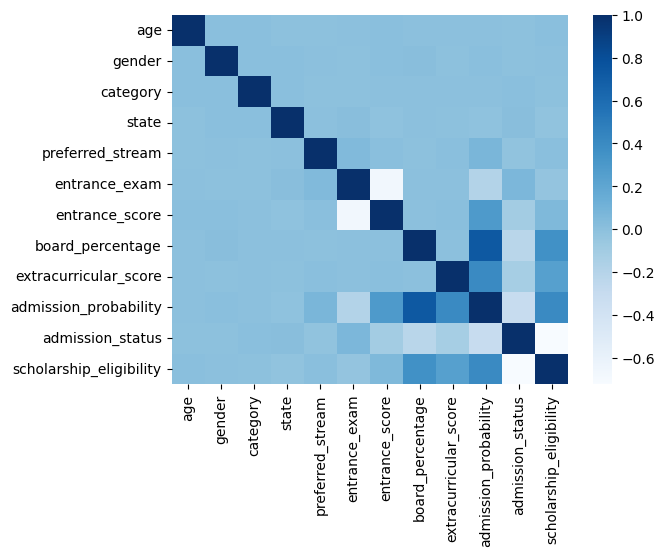

In [28]:
sns.heatmap(df.select_dtypes(["int64", "float64"]).corr(), cmap = "Blues")

**Strong relationships**

- `Board_percentage` ↔ `Admission_probability`: High board exam performance strongly increases admission chances.

- `Admission_probability` ↔ `Admission_status`: As expected, higher probability directly leads to confirmed admission.

- `Admission_status` ↔ `Scholarship_eligibility`: Students who get admission are more likely to be scholarship-eligible.

- `Board_percentage` ↔ `Scholarship_eligibility`: Academic consistency plays a key role in scholarships.

**Moderate relationships**

- `Entrance_score` ↔ `Admission_probability`: Entrance exam scores contribute meaningfully but less than board marks.

- `Extracurricular_score` ↔ `Admission_probability / Scholarship_eligibility`: Extracurriculars support outcomes but are not dominant factors.

  

In [29]:
X = df.drop(columns = ["admission_probability","scholarship_eligibility","admission_status"] )
Y = df["admission_probability"]

In [30]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.2, random_state = 42)

In [31]:
model = LinearRegression()

In [32]:
model.fit(X_train, Y_train)

LinearRegression()

In [33]:
Y_pred = model.predict(X_test)

In [34]:
r2_score(Y_test, Y_pred)

0.7767280681023159

In [35]:
with open("admission_prediction_model.pkl", "wb") as f:
    pickle.dump(model, f)